In [80]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rossmann-store-sales/sample_submission.csv
/kaggle/input/competitions/rossmann-store-sales/store.csv
/kaggle/input/competitions/rossmann-store-sales/train.csv
/kaggle/input/competitions/rossmann-store-sales/test.csv


## 1. Import Necessary Libraries :

In [81]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error,root_mean_squared_error,r2_score,mean_absolute_error
import joblib

import warnings 
warnings.filterwarnings("ignore")

## 2. Import Dataset :

In [3]:
rossmann_sales_data = pd.read_csv("/kaggle/input/competitions/rossmann-store-sales/train.csv")
rossmann_sales_data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


## 3. Data Understanding :

In [4]:
rossmann_sales_data.shape

(1017209, 9)

In [5]:
rossmann_sales_data.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [6]:
rossmann_sales_data.dtypes

Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object

In [7]:
rossmann_sales_data["Date"] = pd.to_datetime(rossmann_sales_data["Date"])
rossmann_sales_data.dtypes

Store                     int64
DayOfWeek                 int64
Date             datetime64[ns]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object

## 4. Data Preperation :

### 4.1 Feature Engineering: Extracting Information from the Date Column :

The **Date** column contains valuable time-related information, but machine learning models cannot directly interpret raw date values. Therefore, the date is transformed into multiple numerical features that help the model learn temporal patterns and seasonal trends in sales.

**Features Extracted:**

- **Year:** Captures long-term trends across different years.
- **Month:** Helps identify monthly and seasonal sales patterns.
- **Day:** Represents the day of the month, which may influence customer purchasing behavior.
- **Week:** Captures weekly sales trends throughout the year.
- **Quarter:** Groups months into business quarters to represent seasonal demand.
- **IsWeekend:** Indicates whether a record falls on a weekend, as sales often differ between weekdays and weekends.

**Why is this necessary?**

- Machine learning algorithms cannot directly understand date values.
- Converting dates into meaningful numerical features allows the model to identify trends, seasonality, and customer purchasing patterns.
- After extracting these features, the original **Date** column becomes redundant and is removed from the dataset.

In [8]:
rossmann_sales_data["Year"] = rossmann_sales_data["Date"].dt.year
rossmann_sales_data["Month"] = rossmann_sales_data["Date"].dt.month
rossmann_sales_data["Day"] = rossmann_sales_data["Date"].dt.day
rossmann_sales_data["Week"] = rossmann_sales_data["Date"].dt.isocalendar().week.astype(int)
rossmann_sales_data["Quarter"] = rossmann_sales_data["Date"].dt.quarter
rossmann_sales_data["IsWeekend"] = (rossmann_sales_data["Date"].dt.dayofweek >= 5).astype(int)

In [9]:
rossmann_sales_data.drop(columns = "Date", inplace=True)
rossmann_sales_data.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,Week,Quarter,IsWeekend
0,1,5,5263,555,1,1,0,1,2015,7,31,31,3,0
1,2,5,6064,625,1,1,0,1,2015,7,31,31,3,0
2,3,5,8314,821,1,1,0,1,2015,7,31,31,3,0
3,4,5,13995,1498,1,1,0,1,2015,7,31,31,3,0
4,5,5,4822,559,1,1,0,1,2015,7,31,31,3,0


In [10]:
rossmann_sales_data.columns

Index(['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'Week',
       'Quarter', 'IsWeekend'],
      dtype='object')

### 4.2 Seperating Numerical & Categorical Features :

In [11]:
cat_cols = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Quarter",
    "IsWeekend"
]

num_cols = [
    "Customers",
    "Year",
    "Month",
    "Day",
    "Week"
]

target = "Sales"

In [12]:
rossmann_sales_data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Year,1017209.0,2013.832292,0.777396,2013.0,2013.0,2014.0,2014.0,2015.0
Month,1017209.0,5.846762,3.326097,1.0,3.0,6.0,8.0,12.0
Day,1017209.0,15.702790,8.787638,1.0,8.0,16.0,23.0,31.0
Week,1017209.0,23.615515,14.433381,1.0,11.0,22.0,35.0,52.0


### Data Fields

Most of the fields are self-explanatory. The following are descriptions for those that aren't.

- **Id** - An Id that represents a (Store, Date) duple within the test set.

- **Store** - A unique Id for each store.

- **Sales** - The turnover for any given day. This is the target variable being predicted.

- **Customers** - The number of customers on a given day.

- **Open** - An indicator for whether the store was open: `0 = closed`, `1 = open`.

- **StateHoliday** - Indicates a state holiday. Normally all stores, with few exceptions, are closed on state holidays. `a = public holiday`, `b = Easter holiday`, `c = Christmas`, `0 = None`.

- **SchoolHoliday** - Indicates if the `(Store, Date)` was affected by the closure of public schools.

- **StoreType** - Differentiates between 4 different store models: `a`, `b`, `c`, `d`.

- **Assortment** - Describes an assortment level: `a = basic`, `b = extra`, `c = extended`.

- **CompetitionDistance** - Distance in meters to the nearest competitor store.

- **CompetitionOpenSince[Month/Year]** - Gives the approximate year and month when the nearest competitor was opened.

- **Promo** - Indicates whether a store is running a promotion on that day.

- **Promo2** - A continuing and consecutive promotion for some stores: `0 = store is not participating`, `1 = store is participating`.

- **Promo2Since[Year/Week]** - Describes the year and calendar week when the store started participating in Promo2.

- **PromoInterval** - Describes the consecutive intervals in which Promo2 is started, naming the months when the promotion is started anew.  
  For example, `"Feb,May,Aug,Nov"` means each promotion round starts in February, May, August, and November of any given year.

#### 4.2.1 Univariate Analysis :

#### Target Feature :

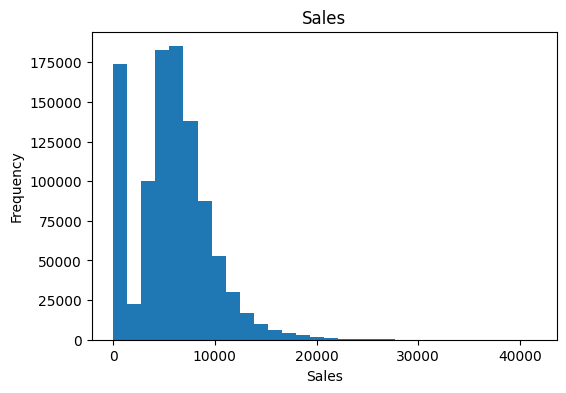

In [13]:
    plt.figure(figsize=(6,4))
    plt.hist(rossmann_sales_data[target], bins=30)
    plt.title(target)
    plt.xlabel(target)
    plt.ylabel("Frequency")
    plt.show()

### Observations

- The Sales distribution is highly right-skewed.
- Most sales values are concentrated between approximately 3,000 and 10,000.
- A noticeable concentration of values occurs near zero, which can be associated with store closure days.
- A small number of observations have very high sales values, creating a long right tail.
- The high values should not be removed automatically because they may represent genuine high-sales days.
- The distribution suggests that store operating status and other business factors may have a strong influence on sales.

#### Numerical Features :

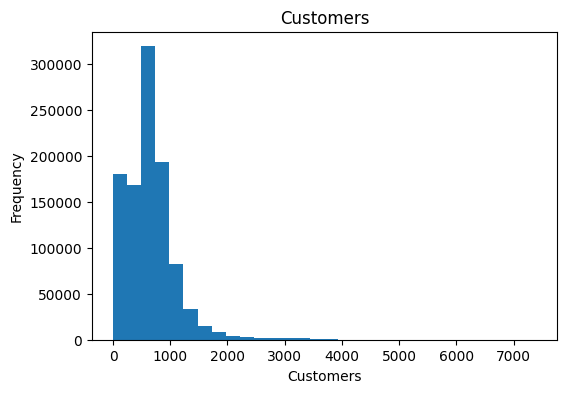

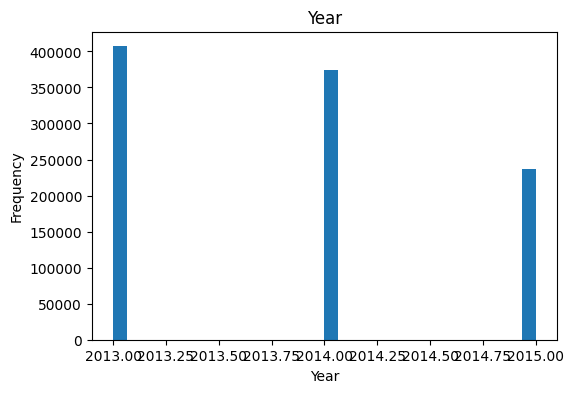

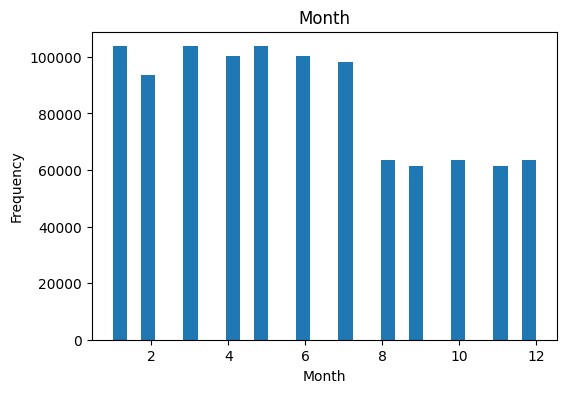

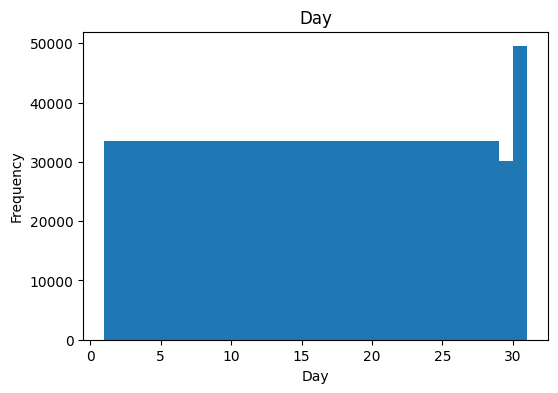

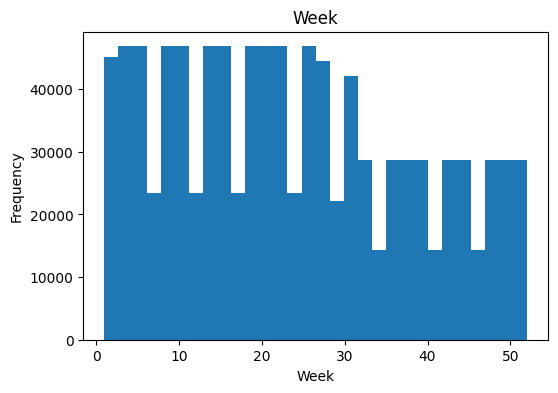

In [14]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.hist(rossmann_sales_data[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Observations

* Customers is right-skewed, with most observations concentrated at lower customer counts.
* A small number of stores have very high customer counts, creating a long right tail.
* Year contains only three years: 2013, 2014, and 2015.
* Month is distributed across all 12 months, with higher frequencies in the earlier months and comparatively lower frequencies from August onwards.
* Day is fairly evenly distributed across the days of the month.
* Week shows varying frequencies across the weeks, with generally higher observations in the earlier weeks and lower frequencies in some later weeks.
* No immediate data-quality issue is evident from these distributions.

#### Categorical Features :

In [15]:
for col in cat_cols:
    print(rossmann_sales_data[col].value_counts())

Store
1115    942
1       942
2       942
3       942
4       942
       ... 
32      758
36      758
41      758
1092    758
1094    758
Name: count, Length: 1115, dtype: int64
DayOfWeek
5    145845
4    145845
3    145665
2    145664
1    144730
7    144730
6    144730
Name: count, dtype: int64
Open
1    844392
0    172817
Name: count, dtype: int64
Promo
0    629129
1    388080
Name: count, dtype: int64
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64
SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64
Quarter
2    304395
1    301049
3    223165
4    188600
Name: count, dtype: int64
IsWeekend
0    727749
1    289460
Name: count, dtype: int64


### Understanding the `StateHoliday` Feature

The **StateHoliday** column indicates whether a particular day is a state holiday and specifies the type of holiday. Since holidays can significantly influence customer footfall and purchasing behavior, this feature is expected to have an impact on sales.

**StateHoliday Categories:**

- **0:** No state holiday (Regular working day)
- **a:** Public Holiday
- **b:** Easter Holiday
- **c:** Christmas Holiday

This feature is categorical in nature and will be encoded before training the machine learning models so that the algorithms can effectively utilize the information.

In [16]:
for value in rossmann_sales_data["StateHoliday"].unique():
    print(value, type(value))

0 <class 'str'>
a <class 'str'>
b <class 'str'>
c <class 'str'>
0 <class 'int'>


In [17]:
rossmann_sales_data["StateHoliday"] = rossmann_sales_data["StateHoliday"].astype("str")
rossmann_sales_data["StateHoliday"].value_counts()

StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64

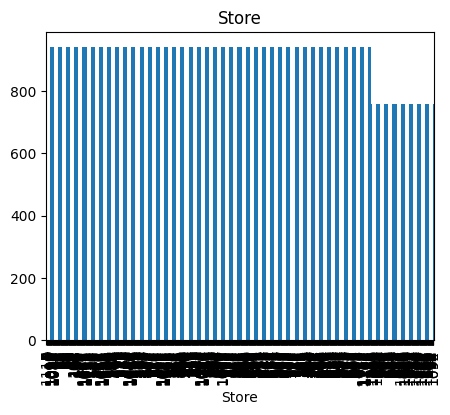

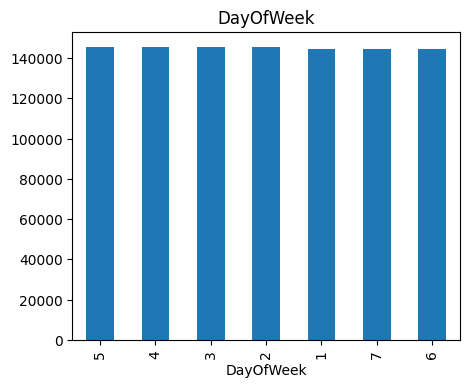

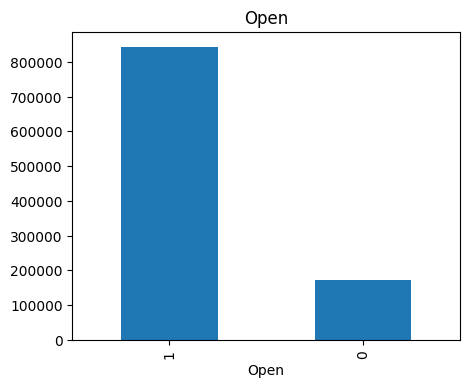

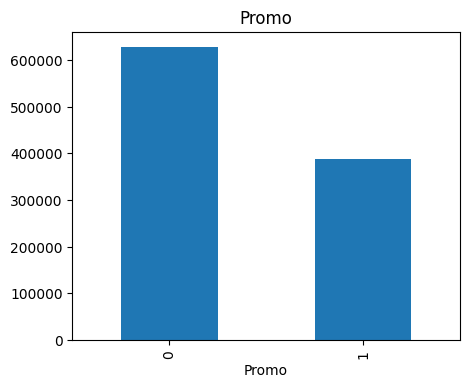

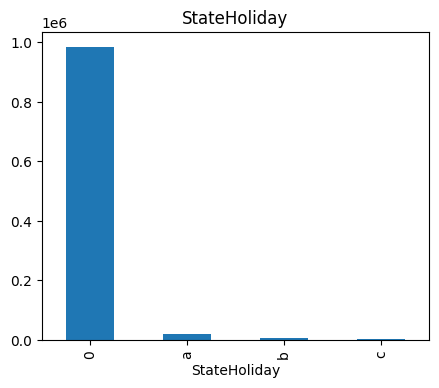

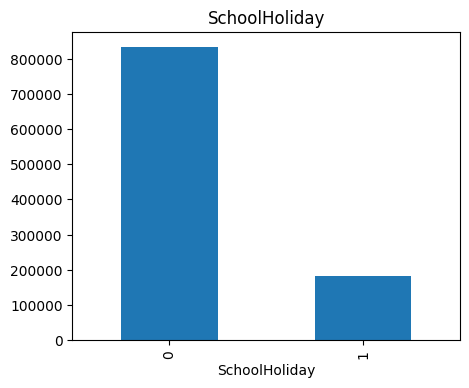

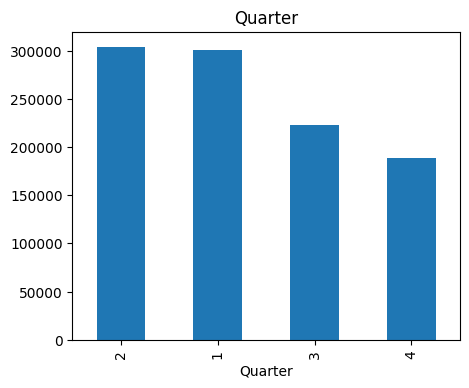

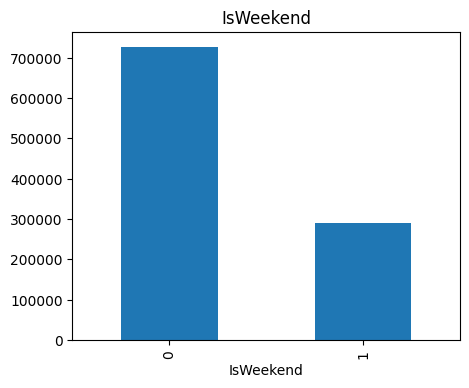

In [18]:
for col in cat_cols:
    rossmann_sales_data[col].value_counts().plot(kind="bar", figsize=(5,4))
    plt.title(col)
    plt.show()

### Observations

* **Store:** Most stores have a similar number of observations, although some stores have noticeably fewer records than the others.

* **DayOfWeek:** The observations are almost evenly distributed across all seven days, indicating no major class imbalance.

* **Open:** Most records correspond to stores being open (`1`), while a smaller proportion of records correspond to stores being closed (`0`).

* **Promo:** Non-promotion days (`0`) are more frequent than promotion days (`1`).

* **StateHoliday:** The vast majority of observations are non-holiday days (`0`). Public, Easter, and Christmas holidays occur much less frequently.

* **SchoolHoliday:** Most observations correspond to non-school-holiday days (`0`), while school-holiday days (`1`) are less frequent.

* **Quarter:** Q1 and Q2 contain the highest number of observations, followed by Q3 and Q4.

* **IsWeekend:** Weekdays (`0`) are considerably more frequent than weekends (`1`), which is expected because the dataset contains more working days.

### 4.2.2 Bivariate Analysis :

#### Numerical Feature vs Target :

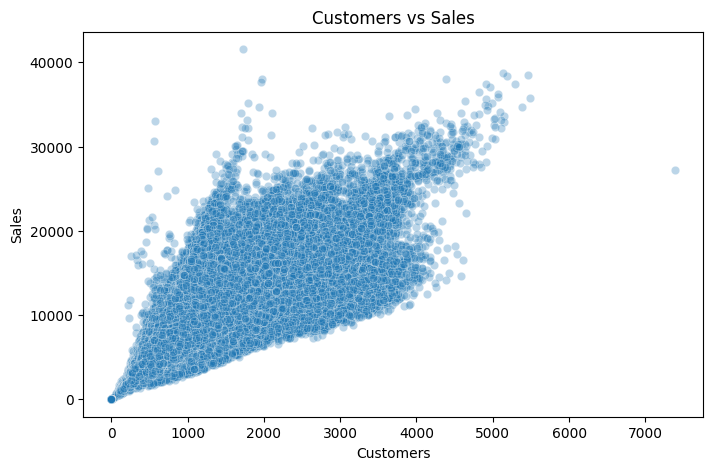

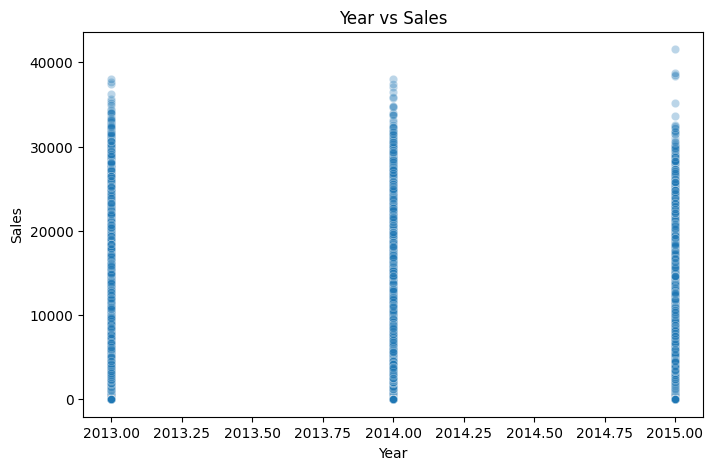

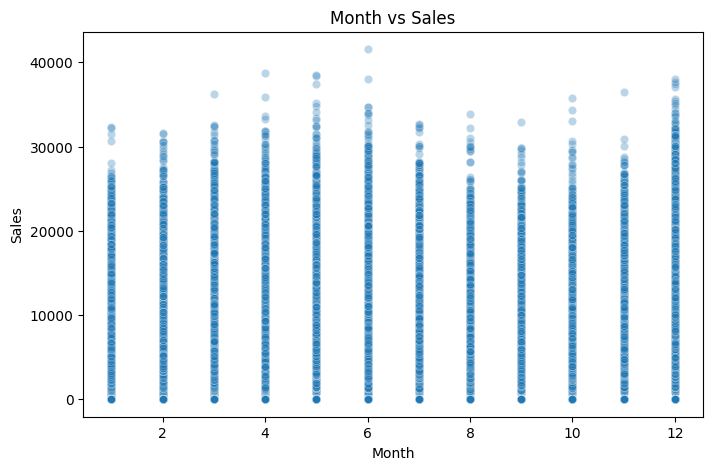

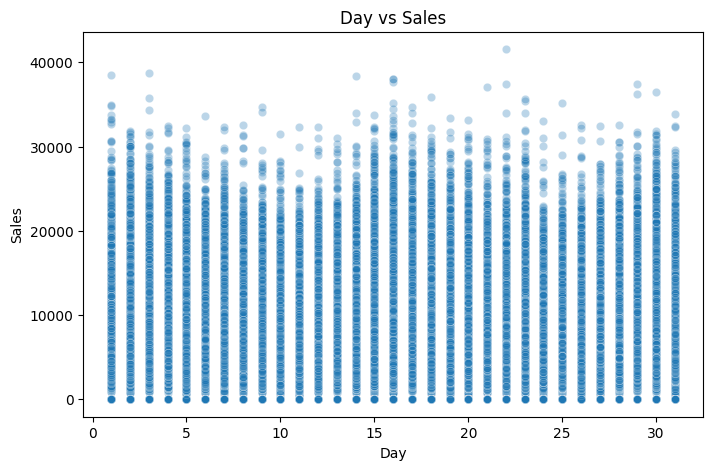

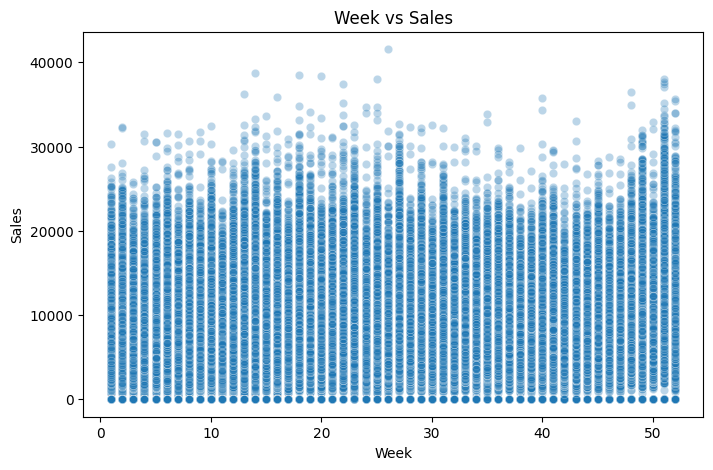

In [19]:
for col in num_cols:

    plt.figure(figsize=(8, 5))

    sns.scatterplot(
        data=rossmann_sales_data,
        x=col,
        y="Sales",
        alpha=0.3
    )

    plt.title(f"{col} vs Sales")
    plt.xlabel(col)
    plt.ylabel("Sales")

    plt.show()

### Observations from Numerical Features vs Sales

* **Customers vs Sales**
  - There is a clear positive relationship between Customers and Sales.
  - As the number of customers increases, sales generally increase.
  - The relationship is not perfectly linear because the spread of Sales becomes wider at higher customer counts.
  - A few observations have unusually high customer counts and sales.
  - Customers appears to be a strong predictor of Sales.

* **Year vs Sales**
  - Sales distributions are present across 2013, 2014, and 2015.
  - The overall sales range is broadly similar across the three years.
  - 2015 contains some of the highest observed sales values.
  - Since Year has only three distinct values, treating it as a continuous numerical variable provides limited information from this scatter plot.
  - Year may still capture a temporal trend, but its relationship with Sales should be investigated further using grouped statistics or time-series analysis.

* **Month vs Sales**
  - Sales values are widely distributed across all months.
  - There is no clear linear relationship between Month and Sales.
  - Some months contain more high-sales observations than others.
  - The distribution suggests possible seasonal patterns that may not be captured by a simple scatter plot.
  - Month should therefore be investigated further using monthly average or median Sales.

* **Day vs Sales**
  - There is no strong clear linear relationship between the day of the month and Sales.
  - Sales vary considerably within almost every day.
  - Some days contain more high-sales observations, but the differences are not consistent enough to indicate a strong direct relationship.
  - Day alone appears to have relatively weak predictive information compared with features such as Customers.

* **Week vs Sales**
  - Sales vary substantially across different weeks of the year.
  - There is no simple linear relationship between Week and Sales.
  - Some periods show higher concentrations of high-sales observations, particularly around certain weeks.
  - The pattern suggests possible seasonal or time-dependent effects.
  - Week may provide useful information when combined with other temporal features rather than being interpreted as a simple continuous variable.

#### Categorical Feature vs Target :

#### Top 20 Stores :

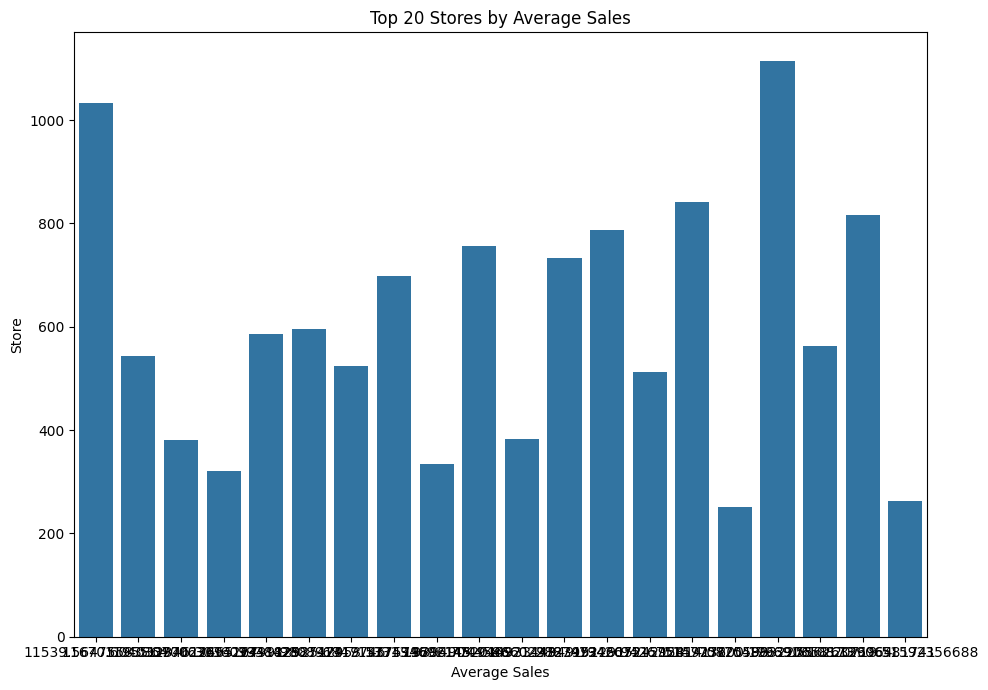

In [20]:
top_20_stores = (
    rossmann_sales_data
    .groupby("Store")["Sales"]
    .mean()
    .sort_values(ascending=True)
    .tail(20)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=top_20_stores.values,
    y=top_20_stores.index
)

plt.title("Top 20 Stores by Average Sales")
plt.xlabel("Average Sales")
plt.ylabel("Store")

plt.tight_layout()
plt.show()

#### Bottom 20 Stores :

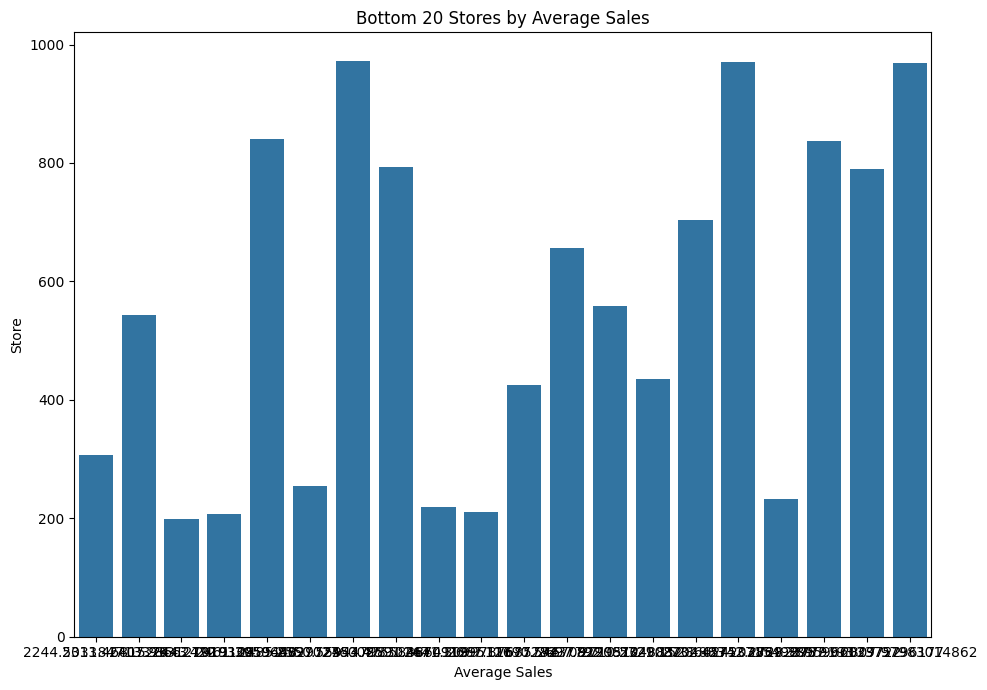

In [21]:
bottom_20_stores = (
    rossmann_sales_data
    .groupby("Store")["Sales"]
    .mean()
    .sort_values(ascending=True)
    .head(20)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    x=bottom_20_stores.values,
    y=bottom_20_stores.index
)

plt.title("Bottom 20 Stores by Average Sales")
plt.xlabel("Average Sales")
plt.ylabel("Store")

plt.tight_layout()
plt.show()

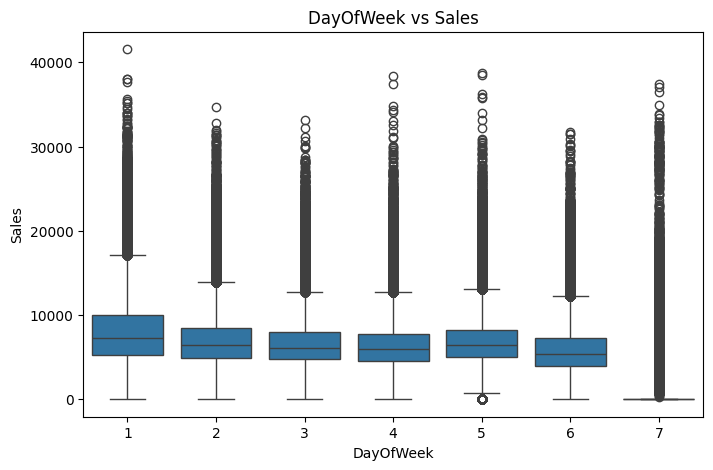

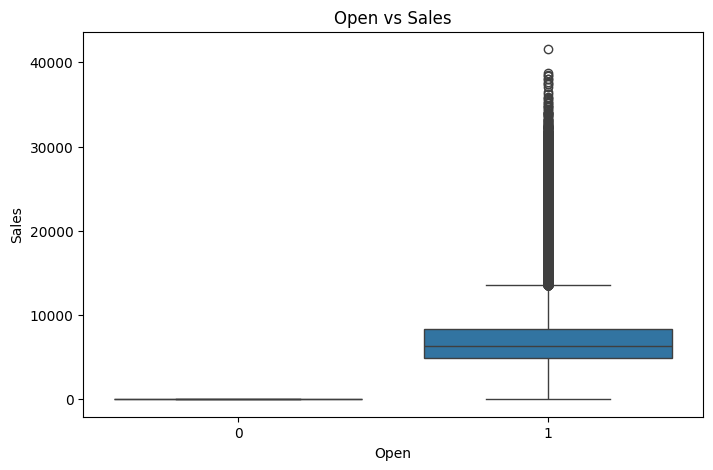

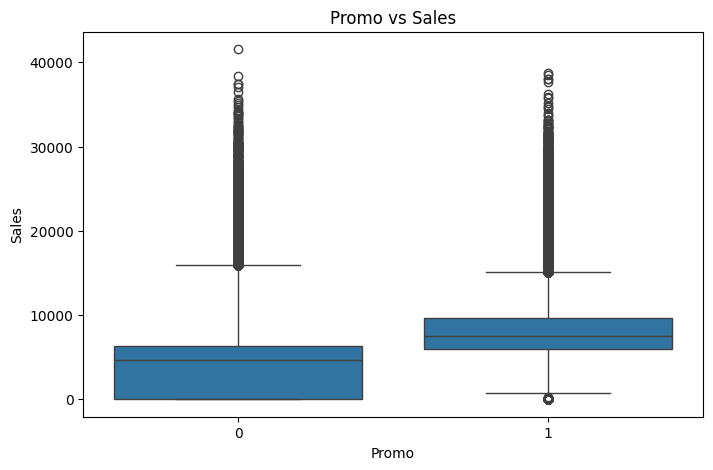

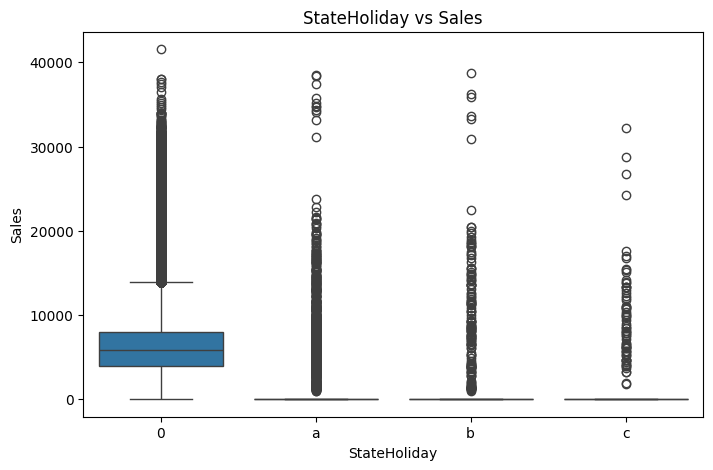

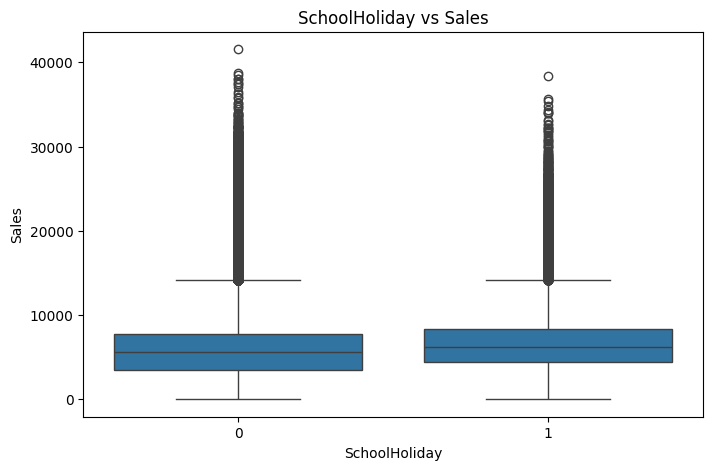

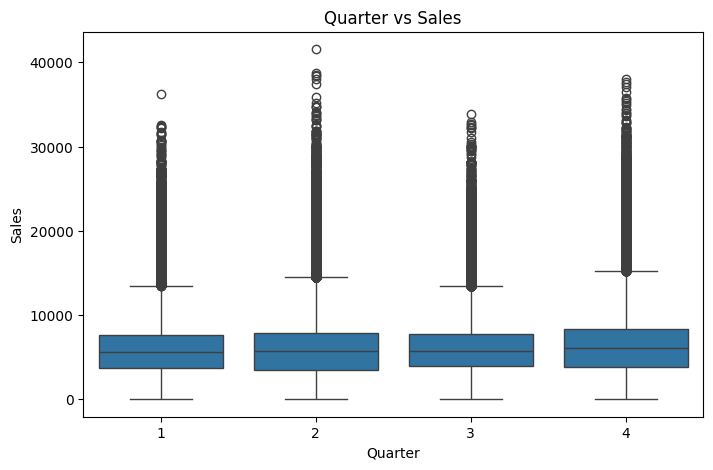

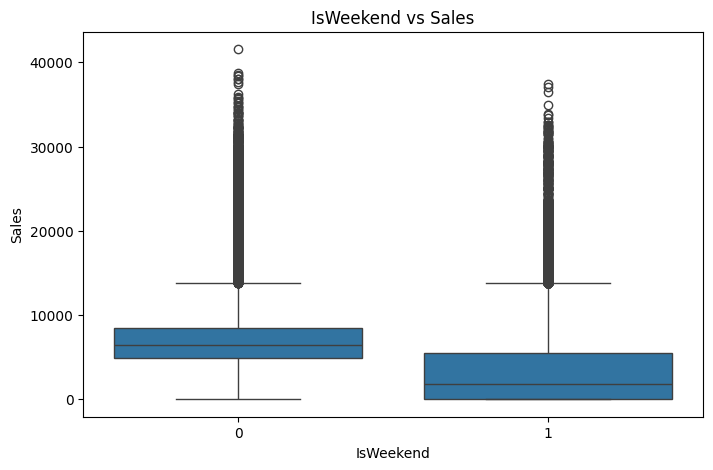

In [22]:
for col in cat_cols[1:]:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=rossmann_sales_data,
        x=col,
        y="Sales"
    )

    plt.title(f"{col} vs Sales")
    plt.xlabel(col)
    plt.ylabel("Sales")

    plt.show()

### Observations from Categorical Features vs Sales

* **Store vs Sales**
  - Average sales vary considerably across different stores.
  - Store 262 has the highest average sales among the top 20 stores, followed by stores such as 817, 562, and 1114.
  - The bottom 20 stores have substantially lower average sales compared with the top-performing stores.
  - This indicates that store-level characteristics have a strong relationship with sales.
    

* **DayOfWeek vs Sales**
  - Sales distributions vary across different days of the week.
  - Day 1 (Monday) has one of the highest median sales values.
  - Day 7 (Sunday) has very low sales compared with the other days.
  - Day 5 (Friday) also shows relatively high median sales.
  - There are many high-value outliers across most days, indicating occasional periods of unusually high sales.
  - Day of the week appears to have a meaningful relationship with sales.

* **Open vs Sales**
  - Stores with `Open = 0` have sales close to zero because the stores are closed.
  - Stores with `Open = 1` have substantially higher sales.
  - The distribution for open stores is much wider and contains many high-value observations.
  - Store operating status has a very strong relationship with sales.

* **Promo vs Sales**
  - Stores running a promotion (`Promo = 1`) generally have a higher median sales value than stores without a promotion (`Promo = 0`).
  - The sales distribution for promoted stores is shifted towards higher values.
  - Both groups contain several high-sales outliers.
  - This suggests that promotions are associated with increased sales.

* **StateHoliday vs Sales**
  - Most observations belong to `StateHoliday = 0`, meaning there is no state holiday.
  - The sales distribution for non-holiday days is considerably higher than the holiday categories.
  - Categories `a`, `b`, and `c` contain very low typical sales values, with several high-value outliers.
  - State holidays therefore appear to have a strong relationship with sales, although the holiday categories are highly imbalanced.

* **SchoolHoliday vs Sales**
  - The median sales value for `SchoolHoliday = 1` is slightly higher than for `SchoolHoliday = 0`.
  - Both categories have a similar overall spread and contain many high-value outliers.
  - The difference between the two groups is relatively small compared with features such as `Open` and `Promo`.
  - School holiday status may have some relationship with sales, but its effect appears weaker.

* **Quarter vs Sales**
  - Sales distributions differ across the four quarters.
  - Quarter 4 has the highest median sales among the four quarters.
  - Quarter 1 has a relatively lower median sales value.
  - Quarter 2 and Quarter 3 have fairly similar distributions.
  - There are many high-sales outliers across all quarters.
  - This suggests that seasonal effects may influence sales.

* **IsWeekend vs Sales**
  - Weekdays (`IsWeekend = 0`) have a considerably higher median sales value than weekends (`IsWeekend = 1`).
  - Weekend sales show a wider concentration towards lower values.
  - Both groups contain high-sales outliers.
  - This indicates that weekend status has a noticeable relationship with sales.

## 5. Feature Engineering :

In [23]:
rossmann_sales_data["Year"].value_counts().sort_index()

Year
2013    406974
2014    373855
2015    236380
Name: count, dtype: int64

In [24]:
rossmann_sales_data[["Year", "Month", "Day"]].head()

,Year,Month,Day
0,2015,7,31
1,2015,7,31
2,2015,7,31
3,2015,7,31
4,2015,7,31


In [25]:
rossmann_sales_data["Date"] = pd.to_datetime(rossmann_sales_data[["Year", "Month", "Day"]])
rossmann_sales_data = rossmann_sales_data.sort_values("Date").reset_index(drop=True)
rossmann_sales_data[["Date", "Year", "Month", "Day"]].head()

,Date,Year,Month,Day
0,2013-01-01,2013,1,1
1,2013-01-01,2013,1,1
2,2013-01-01,2013,1,1
3,2013-01-01,2013,1,1
4,2013-01-01,2013,1,1


In [26]:
rossmann_sales_data[["Date", "Year", "Month", "Day"]].tail()

,Date,Year,Month,Day
1017204,2015-07-31,2015,7,31
1017205,2015-07-31,2015,7,31
1017206,2015-07-31,2015,7,31
1017207,2015-07-31,2015,7,31
1017208,2015-07-31,2015,7,31


#### Removing "Customers" :
We are decided to do True future forecasting , So we don't need customers feature ,because we're trying to predict tomorrow's sales. We don't know tomorrow's customer count yet. But your dataset gives us the actual customer count for that day.

In [27]:
rossmann_sales_data.drop(columns=["Customers"], inplace=True)

In [28]:
# Make sure the data is sorted by Store and Date
rossmann_sales_data = rossmann_sales_data.sort_values(
    by=["Store", "Date"]
).reset_index(drop=True)

rossmann_sales_data[["Store", "Date", "Sales"]].head(10)

,Store,Date,Sales
0,1,2013-01-01,0
1,1,2013-01-02,5530
2,1,2013-01-03,4327
3,1,2013-01-04,4486
4,1,2013-01-05,4997
5,1,2013-01-06,0
6,1,2013-01-07,7176
7,1,2013-01-08,5580
8,1,2013-01-09,5471
9,1,2013-01-10,4892


## 6. Lag Featuring :

In [29]:
rossmann_sales_data["Sales_lag_1"] = (rossmann_sales_data.groupby("Store")["Sales"].shift(1))
rossmann_sales_data[["Store","Date","Sales","Sales_lag_1"]].head(10)

,Store,Date,Sales,Sales_lag_1
0,1,2013-01-01,0,NaN
1,1,2013-01-02,5530,0.0
2,1,2013-01-03,4327,5530.0
3,1,2013-01-04,4486,4327.0
4,1,2013-01-05,4997,4486.0
5,1,2013-01-06,0,4997.0
6,1,2013-01-07,7176,0.0
7,1,2013-01-08,5580,7176.0
8,1,2013-01-09,5471,5580.0
9,1,2013-01-10,4892,5471.0


### Now Creating 7-day Lag to compare the sales for the same day on previous week :

In [30]:
rossmann_sales_data["Sales_lag_7"] = (rossmann_sales_data.groupby("Store")["Sales"].shift(7))
rossmann_sales_data[["Store","Date","Sales","Sales_lag_1","Sales_lag_7"]].head(15)

,Store,Date,Sales,Sales_lag_1,Sales_lag_7
0,1,2013-01-01,0,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN
2,1,2013-01-03,4327,5530.0,NaN
3,1,2013-01-04,4486,4327.0,NaN
4,1,2013-01-05,4997,4486.0,NaN
5,1,2013-01-06,0,4997.0,NaN
6,1,2013-01-07,7176,0.0,NaN
7,1,2013-01-08,5580,7176.0,0.0
8,1,2013-01-09,5471,5580.0,5530.0
9,1,2013-01-10,4892,5471.0,4327.0


## 7. Rolling Average :

#### 7 - Day Rolling Average :

In [31]:
rossmann_sales_data["Sales_Rolling_7"] = (rossmann_sales_data.groupby("Store")["Sales"].transform(
    lambda x:x.shift(1).rolling(window=7).mean()))
rossmann_sales_data[["Store","Date","Sales","Sales_lag_1","Sales_lag_7","Sales_Rolling_7"]].head(15)

,Store,Date,Sales,Sales_lag_1,Sales_lag_7,Sales_Rolling_7
0,1,2013-01-01,0,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,3788.000000
8,1,2013-01-09,5471,5580.0,5530.0,4585.142857
9,1,2013-01-10,4892,5471.0,4327.0,4576.714286


#### 30 - Day Rolling Average :

In [32]:
rossmann_sales_data["Sales_Rolling_30"] = (rossmann_sales_data.groupby("Store")["Sales"].transform(
    lambda x:x.shift(1).rolling(window=30).mean()))
rossmann_sales_data[["Store","Date","Sales","Sales_lag_1","Sales_lag_7","Sales_Rolling_7",
                     "Sales_Rolling_30"]].head(40)

,Store,Date,Sales,Sales_lag_1,Sales_lag_7,Sales_Rolling_7,Sales_Rolling_30
0,1,2013-01-01,0,NaN,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN,NaN
2,1,2013-01-03,4327,5530.0,NaN,NaN,NaN
3,1,2013-01-04,4486,4327.0,NaN,NaN,NaN
4,1,2013-01-05,4997,4486.0,NaN,NaN,NaN
5,1,2013-01-06,0,4997.0,NaN,NaN,NaN
6,1,2013-01-07,7176,0.0,NaN,NaN,NaN
7,1,2013-01-08,5580,7176.0,0.0,3788.000000,NaN
8,1,2013-01-09,5471,5580.0,5530.0,4585.142857,NaN
9,1,2013-01-10,4892,5471.0,4327.0,4576.714286,NaN


### Handling Missing Values After Creating Time-Series Features

* Lag and rolling features naturally create `NaN` values at the beginning of the dataset because there is not enough historical data available for those dates.

* `Sales_Lag_1` requires at least one previous day's sales.

* `Sales_Lag_7` requires at least seven previous days of sales.

* `Sales_Rolling_7` requires seven previous observations to calculate the rolling average.

* `Sales_Rolling_30` requires thirty previous observations to calculate the rolling average.

* These `NaN` values do not represent missing sales. They simply mean that sufficient historical information was not available for those dates.

* We should not replace these values with `0`, because `0` would incorrectly imply that the previous sales or rolling average was actually zero.

* Therefore, rows without sufficient historical information will be removed before model training.

* After removing these rows, the remaining observations will have all the required lag and rolling features available.

* This keeps the forecasting dataset clean while preserving the actual historical sales information.

### Important Point

* The lag and rolling features were created using previous observations only.

* This prevents future information from leaking into the model.

* Therefore, the forecasting features are suitable for the next stage of the time-series pipeline.

In [33]:
rossmann_sales_data = rossmann_sales_data.dropna(
    subset=[
        "Sales_lag_1",
        "Sales_lag_7",
        "Sales_Rolling_7",
        "Sales_Rolling_30"
    ]
).reset_index(drop=True)

rossmann_sales_data[["Store","Date","Sales","Sales_lag_1","Sales_lag_7","Sales_Rolling_7",
                     "Sales_Rolling_30"]].head(10)

,Store,Date,Sales,Sales_lag_1,Sales_lag_7,Sales_Rolling_7,Sales_Rolling_30
0,1,2013-01-31,4709,4601.0,5195.0,4108.571429,4124.066667
1,1,2013-02-01,5633,4709.0,5586.0,4039.142857,4281.033333
2,1,2013-02-02,5970,5633.0,5598.0,4045.857143,4284.466667
3,1,2013-02-03,0,5970.0,0.0,4099.000000,4339.233333
4,1,2013-02-04,7032,0.0,4055.0,4099.000000,4189.700000
5,1,2013-02-05,6049,7032.0,3725.0,4524.285714,4257.533333
6,1,2013-02-06,6140,6049.0,4601.0,4856.285714,4459.166667
7,1,2013-02-07,5499,6140.0,4709.0,5076.142857,4424.633333
8,1,2013-02-08,5681,5499.0,5633.0,5189.000000,4421.933333
9,1,2013-02-09,5370,5681.0,5970.0,5195.857143,4428.933333


#### Sort by date :

Even though our data currently appears ordered, let's explicitly guarantee it:

In [34]:
rossmann_sales_data = rossmann_sales_data.sort_values("Date").reset_index(drop=True)

## 8. Time Based Train Test split :

In [35]:
print("Min Date :",rossmann_sales_data["Date"].min()) 
print("Max Date :",rossmann_sales_data["Date"].max())

Min Date : 2013-01-31 00:00:00
Max Date : 2015-07-31 00:00:00


### Date Range After Feature Engineering

* After creating the lag and rolling features, the first 30 days were removed because sufficient historical data was required for the rolling features.

* The resulting dataset starts from **2013-01-31**.

* The dataset ends on **2015-07-31**.

* Therefore, the available forecasting period is from **2013-01-31 to 2015-07-31**.

* This date range will be used to create a **time-based train-test split**.

* The training data will contain the earlier period, while the final period will be kept completely unseen for testing.

* A fixed date cutoff will be used instead of random splitting because this is a **time-series forecasting problem**.

In [36]:
cutoff_date = "2015-05-31"

train_data = rossmann_sales_data[
    rossmann_sales_data["Date"] <= cutoff_date
].copy()

test_data = rossmann_sales_data[
    rossmann_sales_data["Date"] > cutoff_date
].copy()

In [37]:
print("Training period:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Testing period:", test_data["Date"].min(), "to", test_data["Date"].max())

print("Training shape:", train_data.shape)
print("Testing shape:", test_data.shape)

Training period: 2013-01-31 00:00:00 to 2015-05-31 00:00:00
Testing period: 2015-06-01 00:00:00 to 2015-07-31 00:00:00
Training shape: (915744, 18)
Testing shape: (68015, 18)


#### Deciding our Features :

In [38]:
feature_cols = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Year",
    "Month",
    "Day",
    "Week",
    "Quarter",
    "IsWeekend",
    "Sales_lag_1",
    "Sales_lag_7",
    "Sales_Rolling_7",
    "Sales_Rolling_30"
]

target = "Sales"

In [39]:
X_train = train_data[feature_cols]
y_train = train_data[target]

X_test = test_data[feature_cols]
y_test = test_data[target]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (915744, 16)
y_train: (915744,)
X_test: (68015, 16)
y_test: (68015,)


In [40]:
print("Missing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
Store               0
DayOfWeek           0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Year                0
Month               0
Day                 0
Week                0
Quarter             0
IsWeekend           0
Sales_lag_1         0
Sales_lag_7         0
Sales_Rolling_7     0
Sales_Rolling_30    0
dtype: int64

Missing values in X_test:
Store               0
DayOfWeek           0
Open                0
Promo               0
StateHoliday        0
SchoolHoliday       0
Year                0
Month               0
Day                 0
Week                0
Quarter             0
IsWeekend           0
Sales_lag_1         0
Sales_lag_7         0
Sales_Rolling_7     0
Sales_Rolling_30    0
dtype: int64


## 9. Build a Baseline Prediction :

* Before training a machine learning model, a **baseline prediction** is created as a simple reference point.

* The baseline helps us understand whether our machine learning model is actually improving the forecasting performance.

* For this project, the previous day's sales are used as the baseline prediction.

* The `Sales_lag_1` feature contains the sales value from the previous day.

* Therefore, the baseline assumes that **today's sales will be approximately equal to yesterday's sales**.

* This is a simple forecasting approach and does not learn complex relationships between the features.

* The baseline performance will be evaluated using **Mean Absolute Error (MAE)**.

* MAE represents the average absolute difference between the actual sales and the predicted sales.

* After establishing the baseline, the machine learning models can be trained and their performance can be compared against this baseline.

* A good forecasting model should ideally achieve a **lower MAE than the baseline**.

In [41]:
baseline_predictions = X_test["Sales_lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 2846.776358156289


### Baseline Result

* The baseline prediction uses the previous day's sales (`Sales_lag_1`) as the prediction for the current day's sales.

* The baseline model achieved an **MAE of 2846.78**.

* This means that the baseline prediction is off by approximately **2,847 sales on average**.

* This score will be used as our reference point for evaluating the machine learning models.

* Therefore, the trained models should ideally achieve an **MAE lower than 2846.78** to demonstrate an improvement over the baseline.

## 10. Feature Preprocessing :

In [42]:
X_train.dtypes

Store                 int64
DayOfWeek             int64
Open                  int64
Promo                 int64
StateHoliday         object
SchoolHoliday         int64
Year                  int32
Month                 int32
Day                   int32
Week                  int64
Quarter               int32
IsWeekend             int64
Sales_lag_1         float64
Sales_lag_7         float64
Sales_Rolling_7     float64
Sales_Rolling_30    float64
dtype: object

In [43]:
print(rossmann_sales_data["StateHoliday"].unique())

['0' 'b' 'a' 'c']


In [44]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"),["StateHoliday"]) 
    ],
    remainder="passthrough"
)

In [45]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("X_train before:", X_train.shape)
print("X_train after :", X_train_processed.shape)

print("X_test before :", X_test.shape)
print("X_test after  :", X_test_processed.shape)

X_train before: (915744, 16)
X_train after : (915744, 19)
X_test before : (68015, 16)
X_test after  : (68015, 19)


### Feature Preprocessing

* `ColumnTransformer` is used to apply different preprocessing operations to different columns.
* `StateHoliday` is a categorical feature containing values such as `0`, `a`, `b`, and `c`.
* `OneHotEncoder` converts these categories into separate numerical columns.
* `remainder="passthrough"` keeps the remaining features unchanged.
* The encoder is fitted only on the training data and then applied to the test data.
* The original feature set contained 16 columns.
* After one-hot encoding `StateHoliday`, the feature set increased to 19 columns.
* The same preprocessing is applied to both training and testing data to maintain consistency.

## 11. Model Building ,Training ,Testing & Evaluation :

### 11.1 Linear Regression Model :

* Linear Regression is used as the first machine learning model for sales prediction.
* The model is trained using the preprocessed training features.
* The preprocessing step converts categorical features into numerical form so that Linear Regression can use them.
* The model learns the relationship between the historical features and the target variable, `Sales`.
* The trained model will then be used to predict sales for the unseen test period.

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model.fit(X_train_processed, y_train)

In [ ]:
lr_predictions = lr_model.predict(X_test_processed)
lr_predictions.shape

In [ ]:
lr_mae = mean_absolute_error(
    y_test,
    lr_predictions
)

print("Linear Regression MAE:", lr_mae)

### Linear Regression Evaluation

* The Linear Regression model achieved an MAE of approximately **996.20**.
* The baseline model achieved an MAE of approximately **2846.78**.
* Linear Regression therefore performed substantially better than the baseline.
* The lower MAE indicates that the Linear Regression predictions are, on average, much closer to the actual sales values.
* This improvement suggests that the engineered time-based features, such as lag and rolling features, provide useful information for predicting sales.

In [ ]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_predictions
})

comparison.head(10)

In [ ]:
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

non_zero = y_test > 0

lr_mape = np.mean(
    np.abs(
        (y_test[non_zero] - lr_predictions[non_zero])
        / y_test[non_zero]
    )
) * 100


print("Linear Regression MAE :", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²  :", lr_r2)
print("Linear Regression MAPE:", lr_mape, "%")

### Regression Model Evaluation

* **MAE** measures the average absolute difference between actual and predicted sales.
* **RMSE** measures the prediction error while giving more weight to larger errors.
* **R²** measures how much of the variation in sales is explained by the model.
* The Linear Regression model achieved an MAE of approximately **996.20**.
* The RMSE was approximately **1433.51**.
* The R² score was approximately **0.858**, indicating that the model explains about **85.8%** of the variation in sales.
* These results show a substantial improvement over the baseline MAE of **2846.78**.

### Additional Evaluation Metric — MAPE

* MAPE measures the average prediction error as a percentage of the actual sales.
* Since the dataset contains zero-sales observations, MAPE was calculated only for observations where actual Sales > 0.
* The Linear Regression model achieved a MAPE of approximately **14.97%**.
* This means that, on average, the predictions differ from the actual sales by approximately **15%** for non-zero sales observations.

### Actual vs Predicted Plot :

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=lr_predictions,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

### Actual vs Predicted Sales

* The scatter plot compares the actual sales values with the sales predicted by the Linear Regression model.
* The predictions show a strong positive relationship with the actual sales values.
* As actual sales increase, predicted sales generally increase as well.
* The points become more scattered at higher sales values, indicating larger prediction errors for some high-sales observations.
* The model tends to underestimate some of the highest sales values.
* The vertical group of observations around zero actual sales represents zero-sales days, where the model does not always predict zero.
* Overall, the plot indicates that Linear Regression has learned a strong relationship between the features and sales, while still having difficulty with some extreme observations.

### 11.2 Next Model — Random Forest Regressor :

* Linear Regression has provided a strong baseline machine learning model.
* However, Linear Regression mainly captures linear relationships between the features and the target.
* Sales forecasting can contain complex and non-linear relationships between store characteristics, promotions, calendar features, and historical sales.
* Random Forest is a tree-based ensemble model that can capture non-linear relationships and interactions between features.
* The Random Forest model will be trained and evaluated using the same time-based train-test split.
* Its performance will be compared with the baseline and Linear Regression using the same evaluation metrics.
* Random Forest can capture non-linear relationships and interactions between features.
* Because the dataset contains a large number of training observations, a controlled configuration is used to keep training practical.

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

In [ ]:
rf_model.fit(X_train_processed, y_train)

In [ ]:
rf_predictions = rf_model.predict(X_test_processed)

print("Random Forest predictions shape:", rf_predictions.shape)

In [ ]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

non_zero = y_test > 0

rf_mape = np.mean(
    np.abs(
        (y_test[non_zero] - rf_predictions[non_zero])
        / y_test[non_zero]
    )
) * 100

print("Random Forest MAE :", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²  :", rf_r2)
print("Random Forest MAPE:", rf_mape, "%")

### Actual vs Predicted plot :

In [ ]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=rf_predictions,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest — Actual vs Predicted Sales")

plt.show()

### Random Forest Model Evaluation and Actual vs Predicted Sales

* The Random Forest model achieved an **MAE of 538.72**, meaning that its predictions are, on average, approximately 539 sales units away from the actual sales.
* The model achieved an **RMSE of 840.34**, indicating that larger prediction errors have a greater effect on the overall error.
* The **R² score of 0.951** indicates that the model explains approximately **95.1% of the variation in sales**.
* The model achieved a **MAPE of 9.03%** for observations with non-zero actual sales.
* Random Forest significantly outperformed both the baseline model and Linear Regression across the evaluation metrics.
* The Actual vs Predicted Sales plot shows a strong positive relationship between actual and predicted sales.
* The predictions are more closely concentrated around the expected diagonal relationship compared with Linear Regression.
* Some prediction errors and outliers are still present, particularly for very high sales values.
* Overall, the results indicate that Random Forest captures the complex and non-linear relationships in the sales data effectively.

### 11.3 Final Model - XG Boosting Machine :

#### XGBoost Predictions :

* The trained XGBoost model is used to predict sales for the unseen test period.
* The test data is not used during model training.
* These predictions will be evaluated using the same metrics used for Linear Regression and Random Forest.
* The main goal is to determine whether XGBoost can improve upon the Random Forest model.

In [46]:
print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [47]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

In [48]:
xgb_model.fit(X_train_processed,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [49]:
xgb_predictions = xgb_model.predict(X_test_processed)

print("XGBoost predictions shape:", xgb_predictions.shape)

XGBoost predictions shape: (68015,)


In [50]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
xgb_r2 = r2_score(y_test, xgb_predictions)

non_zero = y_test > 0

xgb_mape = np.mean(
    np.abs(
        (y_test[non_zero] - xgb_predictions[non_zero])
        / y_test[non_zero]
    )
) * 100

print("XGBoost MAE :", xgb_mae)
print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R²  :", xgb_r2)
print("XGBoost MAPE:", xgb_mape, "%")

XGBoost MAE : 548.3751831054688
XGBoost RMSE: 832.7913529210063
XGBoost R²  : 0.9520040154457092
XGBoost MAPE: 9.144630149928386 %


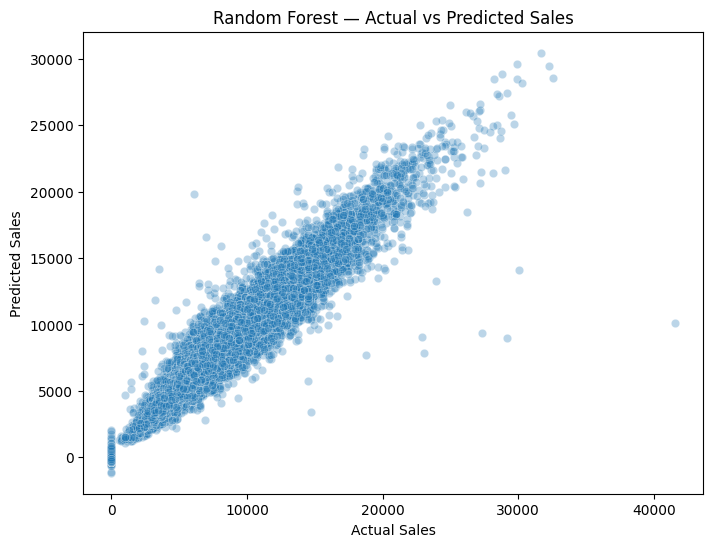

In [51]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=xgb_predictions,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest — Actual vs Predicted Sales")

plt.show()

### XGBoost Model Evaluation

* The XGBoost model achieved an **MAE of 548.38**, meaning that its predictions are, on average, approximately 548 sales units away from the actual sales.
* The model achieved an **RMSE of 832.79**, which indicates the magnitude of prediction errors while giving more weight to larger errors.
* The **R² score of 0.9520** indicates that XGBoost explains approximately **95.2% of the variation in sales**.
* The model achieved a **MAPE of 9.14%** for observations with non-zero actual sales.
* XGBoost significantly outperformed the baseline and Linear Regression models.
* However, Random Forest achieved a slightly lower MAE of **538.72** compared with XGBoost's **548.38**.
* Random Forest also achieved a slightly lower RMSE of **840.34**? Actually, XGBoost's RMSE of **832.79** is lower, indicating that XGBoost performs slightly better when larger errors are considered.
* XGBoost achieved an R² of **0.9520**, which is slightly higher than Random Forest's **0.9511**.
* Random Forest achieved a slightly lower MAPE of **9.03%** compared with XGBoost's **9.14%**.
* Overall, Random Forest and XGBoost perform very similarly, with each model performing better on some metrics.
* The final model should therefore be selected based on the evaluation metric that is most important for the sales forecasting objective.

### Model Comparision Table :

In [55]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        np.nan,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        np.nan,
        lr_r2,
        rf_r2,
        xgb_r2
    ],
    "MAPE": [
        np.nan,
        lr_mape,
        rf_mape,
        xgb_mape
    ]
})

model_comparison

NameError: name 'lr_mae' is not defined

#### Model Performance Comparison

* The models were evaluated using MAE, RMSE, R², and MAPE.
* The baseline provides a reference point for evaluating model improvement.
* Linear Regression improved substantially over the baseline.
* Random Forest achieved the lowest MAE and MAPE among the evaluated models.
* XGBoost achieved slightly better RMSE and R² than Random Forest.
* Overall, Random Forest was selected as the final model because it produced the lowest average and percentage prediction errors.

### RandomForest Feature Importance :

In [56]:
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))
print(processed_feature_names)

Number of processed features: 19
['cat__StateHoliday_0' 'cat__StateHoliday_a' 'cat__StateHoliday_b'
 'cat__StateHoliday_c' 'remainder__Store' 'remainder__DayOfWeek'
 'remainder__Open' 'remainder__Promo' 'remainder__SchoolHoliday'
 'remainder__Year' 'remainder__Month' 'remainder__Day' 'remainder__Week'
 'remainder__Quarter' 'remainder__IsWeekend' 'remainder__Sales_lag_1'
 'remainder__Sales_lag_7' 'remainder__Sales_Rolling_7'
 'remainder__Sales_Rolling_30']


In [57]:
feature_importance = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

NameError: name 'rf_model' is not defined

In [58]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

NameError: name 'feature_importance' is not defined

<Figure size 800x600 with 0 Axes>

#### Random Forest — Feature Importance

* Feature importance was analyzed to understand which features contributed most to the Random Forest predictions.
* **Open** was the most important feature, indicating that store operating status strongly influences the model's sales predictions.
* **Sales_Rolling_30** was the second most important feature, showing that recent 30-period sales behavior provides strong information for predicting future sales.
* **Promo** also had a noticeable contribution to the model's predictions.
* **Sales_lag_1** and **Sales_lag_7** contributed additional information from recent and weekly sales history.
* Calendar-based features such as **Day, Week, DayOfWeek, and Month** had relatively lower importance compared with store status and recent sales features.
* Feature importance represents how useful a feature was for the model's decision-making process and should not be interpreted as a causal relationship.
* Overall, the model relies heavily on the store's operating status and recent sales history when predicting future sales.

### Random Forest — Error Analysis :

In [ ]:
error_analysis = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

error_analysis["Error"] = (
    error_analysis["Actual"] - error_analysis["Predicted"]
)

error_analysis["Absolute_Error"] = (
    error_analysis["Error"].abs()
)

error_analysis.head(10)

#### Random Forest — Error Analysis

* Error analysis is performed to understand where the final Random Forest model makes prediction mistakes.
* The prediction error is calculated as **Actual Sales − Predicted Sales**.
* A positive error indicates that the model **underpredicted** the actual sales.
* A negative error indicates that the model **overpredicted** the actual sales.
* Absolute Error represents the magnitude of the prediction error without considering its direction.
* This analysis helps identify observations where the model's predictions differ substantially from the actual sales.

## 12. Final Forecasting Phase :

### Step 1 — Prepare the Final Historical Dataset :

In [59]:
X_full = rossmann_sales_data[feature_cols]
y_full = rossmann_sales_data[target]

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)

X_full shape: (983759, 16)
y_full shape: (983759,)


#### Final Forecasting

* The model evaluation and comparison have been completed.
* Random Forest was selected as the final model based on its overall performance.
* The final model will now be trained using all available historical data.
* This allows the selected model to learn from the maximum amount of historical sales information before generating future forecasts.

### Step 2 — Retrain the Final Random Forest :

##### Because your X_full still contains the categorical StateHoliday, we need to preprocess it just like we did before.

In [60]:
X_full_processed = preprocessor.fit_transform(X_full)

In [ ]:
final_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_rf_model.fit(X_full_processed, y_full)

print("Final Random Forest trained successfully!")

* A new Random Forest model is created using the selected model configuration.
* The model is trained using all available historical data.
* The preprocessing transformation is fitted on the complete historical feature set.
* Unlike the earlier evaluation model, this final model is not being evaluated on the previous test period.
* The purpose of this step is to allow the final model to learn from the maximum amount of historical information before generating future forecasts.

### Step 3 - Check Historical Date Range  :

In [61]:
print("Last historical date:", rossmann_sales_data["Date"].max())
print("First historical date:", rossmann_sales_data["Date"].min())

Last historical date: 2015-07-31 00:00:00
First historical date: 2013-01-31 00:00:00


#### Step 3.1 — Create the Future Forecast Dates

* A future forecast period of 30 days is created after the last available historical date.
* The future dates represent the period for which sales predictions will be generated.
* Since Rossmann contains multiple stores, each future date will later be combined with every store to create store-level forecasting observations.
* The same feature structure used during model training will be prepared for these future observations.

### Step 4 — Load Original Rossmann Test Data :

In [ ]:
print([name for name in globals() if "test" in name.lower()])

In [62]:
rossmann_test = pd.read_csv("/kaggle/input/competitions/rossmann-store-sales/test.csv")

rossmann_test["Date"] = pd.to_datetime(
    rossmann_test["Date"]
)

rossmann_test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


### Step 5 — Prepare the Original Rossmann Test Features :

In [63]:
rossmann_test["Year"] = rossmann_test["Date"].dt.year
rossmann_test["Month"] = rossmann_test["Date"].dt.month
rossmann_test["Day"] = rossmann_test["Date"].dt.day
rossmann_test["Week"] = (
    rossmann_test["Date"].dt.isocalendar().week.astype(int)
)
rossmann_test["Quarter"] = rossmann_test["Date"].dt.quarter
rossmann_test["IsWeekend"] = (
    rossmann_test["Date"].dt.dayofweek >= 5
).astype(int)

rossmann_test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,Week,Quarter,IsWeekend
0,1,1,4,2015-09-17,1.0,1,0,0,2015,9,17,38,3,0
1,2,3,4,2015-09-17,1.0,1,0,0,2015,9,17,38,3,0
2,3,7,4,2015-09-17,1.0,1,0,0,2015,9,17,38,3,0
3,4,8,4,2015-09-17,1.0,1,0,0,2015,9,17,38,3,0
4,5,9,4,2015-09-17,1.0,1,0,0,2015,9,17,38,3,0


* The original Rossmann test dataset contains known future store and business information.
* Calendar features such as Year, Month, Day, Week, Quarter, and IsWeekend are derived from the Date column.
* These features can be calculated directly because the future dates are known.
* The original test dataset does not contain Sales because Sales is the target variable being predicted.
* Therefore, Sales-based lag and rolling features cannot be directly calculated for the official test period.
* The historical training data ends on 2015-07-31, while the official test period begins on 2015-09-17.
* This gap must be handled carefully to avoid using unavailable future Sales information.

### Step 6 — Build a Forecast Model Without Future Sales-Based Features :

#### Step 6.1 — Define Forecast Features :


In [64]:
forecast_features = [
    "Store",
    "DayOfWeek",
    "Open",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Year",
    "Month",
    "Day",
    "Week",
    "Quarter",
    "IsWeekend"
]

print("Number of forecast features:", len(forecast_features))
print(forecast_features)

Number of forecast features: 12
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'IsWeekend']



* The original Random Forest model used historical Sales-based lag and rolling features.
* These features cannot be directly calculated for the official Rossmann test period because future Sales values are unavailable.
* Therefore, a separate forecasting feature set is created using only information that is known for the future test dates.
* A total of 12 features that are available for the future test period are selected.
* Sales-based lag and rolling features are excluded from this forecasting model to avoid using unavailable future information.
* This model will be evaluated on the previously created time-based holdout before being used for the official test forecast.

### Step 7 - Preprocess the Forecast Features :

#### Step 7.1 — Create a new preprocessor :

In [65]:
forecast_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            ["StateHoliday"]
        )
    ],
    remainder="passthrough"
)

In [78]:
X_forecast_train_processed = forecast_preprocessor.fit_transform(
    X_forecast_train
)

X_forecast_test_processed = forecast_preprocessor.transform(
    X_forecast_test
)

print("Forecast training processed shape:",
      X_forecast_train_processed.shape)

print("Forecast test processed shape:",
      X_forecast_test_processed.shape)

Forecast training processed shape: (983759, 15)
Forecast test processed shape: (41088, 15)


#### Step 7.2 — Prepare the holdout data :

In [71]:
X_train_forecast = train_data[forecast_features]
X_test_forecast = test_data[forecast_features]

X_train_forecast_processed = forecast_preprocessor.fit_transform(
    X_train_forecast
)

X_test_forecast_processed = forecast_preprocessor.transform(
    X_test_forecast
)

print("X_train before:", X_train_forecast.shape)
print("X_train after :", X_train_forecast_processed.shape)

print("X_test before :", X_test_forecast.shape)
print("X_test after  :", X_test_forecast_processed.shape)

X_train before: (915744, 12)
X_train after : (915744, 15)
X_test before : (68015, 12)
X_test after  : (68015, 15)


* The forecast model uses only features that are available for the future Rossmann test period.
* StateHoliday is a categorical feature and is converted into numerical features using One-Hot Encoding.
* The remaining numerical features are passed through without modification.
* A separate preprocessing pipeline is used because this forecasting model has a different feature set from the original model.
* The preprocessing pipeline is fitted only on the training data and then applied to the test data.
* The processed features will be used to evaluate the forecast-ready Random Forest before generating predictions for the official Rossmann test dataset.

### Step 8 — Train the Forecast-Ready Random Forest :

In [ ]:
forecast_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

forecast_rf_model.fit(
    X_train_forecast_processed,
    y_train
)

print("Forecast-ready Random Forest trained successfully!")

* A separate Random Forest model is trained using only the 12 features that will be available for the official future test period.
* Sales-based lag and rolling features are excluded because future Sales values are unavailable.
* The model is trained using the same historical training observations used for the original model evaluation.
* This model provides a realistic baseline for forecasting future Rossmann sales without relying on unavailable future Sales information.
* Hyperparameter tuning will be performed after evaluating this initial forecast-ready model.

### Step 9 — Evaluate the Forecast-Ready Random Forest :

In [ ]:
forecast_rf_predictions = forecast_rf_model.predict(X_test_forecast_processed)
print("Forecast-ready predictions shape:",forecast_rf_predictions.shape)

#### Step 9.1 — Calculate MAE :

In [ ]:
forecast_rf_mae = mean_absolute_error(
    y_test,
    forecast_rf_predictions
)

print("Forecast-ready Random Forest MAE:", forecast_rf_mae)

**So the forecast-ready model:**

- Beats the baseline by a huge margin
- Beats Linear Regression
- Is worse than our original Random Forest

**And we now have evidence for something important:**

- The Sales lag and rolling features were extremely valuable to the original Random Forest.

- But 916.97 isn't terrible considering we've removed four of the strongest features.

### Step 10 - Hyperparameter Tuning :

#### Step 10.1 — Create a time-based tuning split :

But we should not use random K-fold validation, because this is time-series data.
We'll create a validation split from the end of train_data, keeping the chronological order.


In [ ]:
tune_split = int(len(X_train_forecast_processed) * 0.8)

X_tune_train = X_train_forecast_processed[:tune_split]
y_tune_train = y_train.iloc[:tune_split]

X_tune_valid = X_train_forecast_processed[tune_split:]
y_tune_valid = y_train.iloc[tune_split:]

print("Tuning training shape:", X_tune_train.shape)
print("Tuning validation shape:", X_tune_valid.shape)

* The forecast-ready Random Forest achieved an MAE of approximately 916.97 on the June–July holdout period.
* Hyperparameter tuning is performed to determine whether the model can achieve better performance.
* Because this is a time-series forecasting problem, the tuning data is split chronologically rather than randomly.
* The earlier portion is used for tuning the model, while the later portion is used as a validation period.
* This preserves the temporal order of the data and reduces the risk of unrealistic validation results.

#### Step 10.2 Tune Using Our Time-Based Validation :

In [ ]:
rf_configs = [
    {
        "n_estimators": 100,
        "max_depth": 15,
        "min_samples_split": 5,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_split": 5,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 150,
        "max_depth": 20,
        "min_samples_split": 5,
        "min_samples_leaf": 1,
        "max_features": 1.0
    },
    {
        "n_estimators": 100,
        "max_depth": 25,
        "min_samples_split": 5,
        "min_samples_leaf": 1,
        "max_features": 1.0
    }
]

#### Why RandomizedSearchCV Was Not Used ?

* An initial RandomizedSearchCV experiment was performed to search for better Random Forest hyperparameters.
* However, the resulting best cross-validation MAE was approximately 1391.84, which was substantially higher than the 916.97 MAE obtained from our forecast-ready Random Forest on the chronological holdout.
* Since this approach was not appropriate for our time-series validation strategy, the RandomizedSearchCV cells were removed from the main workflow.
* More importantly, the default cross-validation approach used by RandomizedSearchCV does not preserve the strict chronological structure required for time-series forecasting.
* In time-series problems, randomly splitting observations for cross-validation can allow the model to learn from observations that occur later in time while validating on earlier observations.
* Therefore, the RandomizedSearchCV result was not considered a reliable representation of future forecasting performance.
* Instead, a chronological tuning-training and validation split is used.
* Each hyperparameter configuration is trained on earlier observations and evaluated on later observations, better matching the real forecasting scenario.

#### Step 10.3 — Evaluate the Tuning Configurations :

In [ ]:
tuning_results = []

for i, params in enumerate(rf_configs, start=1):

    print(f"Training configuration {i}/{len(rf_configs)}...")

    model = RandomForestRegressor(
        **params,
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_tune_train,
        y_tune_train
    )

    predictions = model.predict(
        X_tune_valid
    )

    mae = mean_absolute_error(
        y_tune_valid,
        predictions
    )

    tuning_results.append({
        "Configuration": i,
        "MAE": mae,
        **params
    })

    print(f"Configuration {i} MAE: {mae:.2f}\n")

In [ ]:
tuning_results_df = pd.DataFrame(tuning_results)

tuning_results_df = tuning_results_df.sort_values(
    by="MAE"
).reset_index(drop=True)

tuning_results_df

* Multiple Random Forest configurations are trained using the chronological tuning-training data.
* Each configuration is evaluated on the later tuning-validation period.
* Mean Absolute Error is calculated for every configuration.
* The configuration with the lowest validation MAE is selected as the best hyperparameter configuration.
* This comparison preserves the chronological order of the data and avoids using the final June–July holdout during tuning.

#### Step 10.4 - Train the best tuned configuration on the complete training set :

In [ ]:
best_forecast_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

best_forecast_rf.fit(
    X_train_forecast_processed,
    y_train
)

print("Best tuned forecast-ready Random Forest trained successfully!")

* Configuration 4 achieved the lowest MAE during chronological hyperparameter tuning.
* The selected hyperparameters are used to create the tuned Random Forest model.
* After selecting the best configuration, the model is retrained using the complete historical training dataset.
* The tuning-validation split is no longer needed because the hyperparameters have already been selected.
* The final evaluation will be performed on the untouched June–July test period to determine whether tuning improved the forecast-ready model.

#### Step 10.5 — Evaluate the Tuned Forecast-Ready Model :

In [ ]:
tuned_forecast_predictions = best_forecast_rf.predict(
    X_test_forecast_processed
)

tuned_forecast_mae = mean_absolute_error(
    y_test,
    tuned_forecast_predictions
)

print(
    "Tuned Forecast-ready Random Forest MAE:",
    tuned_forecast_mae
)

* The tuned Random Forest achieved a holdout MAE of approximately 1352.59.
* The original forecast-ready Random Forest achieved a better holdout MAE of approximately 916.97.
* Although the tuned configuration performed best on the tuning-validation period, it did not generalize as well to the untouched June–July test period.
* Therefore, the original forecast-ready Random Forest is retained as the final forecasting model.
* This demonstrates that hyperparameter tuning does not always improve performance on unseen data and that model selection should ultimately be based on performance on an independent holdout period.

##### Therefore ,Final forecasting model → forecast_rf_model (MAE 916.97)

### Step 11 — Prepare the Official Test Data :

In [ ]:
print("Test start date:", rossmann_test["Date"].min())
print("Test end date:", rossmann_test["Date"].max())
print("Test shape:", rossmann_test.shape)

* The original Rossmann test dataset is used for the final sales forecast.
* The complete test period and number of observations are verified before generating predictions.
* Only information that is available in the official test dataset will be used as model input.
* The same 12 future-available features used to train the selected forecast-ready Random Forest will be prepared for the test data.
* Future Sales values are not used because Sales is the target variable being predicted.

In [ ]:
print("Required features:")
print(forecast_features)

print("\nAvailable columns:")
print(rossmann_test.columns.tolist())

print("\nMissing features:")
print([col for col in forecast_features if col not in rossmann_test.columns])

In [ ]:
rossmann_test["Year"] = rossmann_test["Date"].dt.year
rossmann_test["Month"] = rossmann_test["Date"].dt.month
rossmann_test["Day"] = rossmann_test["Date"].dt.day

rossmann_test["Week"] = (
    rossmann_test["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

rossmann_test["Quarter"] = rossmann_test["Date"].dt.quarter

rossmann_test["IsWeekend"] = (
    rossmann_test["Date"].dt.dayofweek >= 5
).astype(int)

In [72]:
X_official_test = rossmann_test[forecast_features]

print("Official test feature shape:", X_official_test.shape)

X_official_test.head()

Official test feature shape: (41088, 12)


,Store,DayOfWeek,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,Week,Quarter,IsWeekend
0,1,4,1.0,1,0,0,2015,9,17,38,3,0
1,3,4,1.0,1,0,0,2015,9,17,38,3,0
2,7,4,1.0,1,0,0,2015,9,17,38,3,0
3,8,4,1.0,1,0,0,2015,9,17,38,3,0
4,9,4,1.0,1,0,0,2015,9,17,38,3,0


* The official Rossmann test dataset contains the original store, promotion, holiday, and date information.
* Calendar features are derived from the Date column for the official test period.
* The same calendar feature definitions used during model development are applied to maintain consistency between training and forecasting data.
* The resulting dataset contains the 12 future-available features required by the selected forecast-ready Random Forest.

### Step 13 - Preprocess the Official Test Features :

In [ ]:
X_official_test_processed = forecast_preprocessor.transform(
    X_official_test
)

print(
    "Official test processed shape:",
    X_official_test_processed.shape
)

* The official test features are transformed using the previously fitted forecast preprocessing pipeline.
* The preprocessing pipeline is not fitted again on the test data to prevent data leakage.
* StateHoliday is converted into the same one-hot encoded representation used during model training.
* The remaining features are passed through unchanged.
* The resulting processed feature matrix must have the same feature structure expected by the selected forecast-ready Random Forest.

### Step 14 — Generate the Final Sales Predictions :

We'll use the selected forecast-ready Random Forest : forecast_rf_model,

Not the tuned best_forecast_rf, because the original forecast-ready model performed better on our untouched holdout:

In [ ]:
final_predictions = forecast_rf_model.predict(
    X_official_test_processed
)

print("Prediction shape:", final_predictions.shape)
print("First 10 predictions:", final_predictions[:10])

### Step 15 - Attaching Prediction to the Rossmann Test data :

In [ ]:
rossmann_predictions = rossmann_test[["Id", "Store", "Date"]].copy()
rossmann_predictions["PredictedSales"] = final_predictions

rossmann_predictions.head(10)

* The final Sales predictions are combined with the corresponding Id, Store, and Date from the official Rossmann test dataset.
* Each prediction is therefore linked to its original store-date observation.
* The resulting dataframe provides a clear and interpretable representation of the final forecast.
* This dataframe can be used for further analysis, visualization, or submission preparation.

### Step 16 - Analyze the Final Forecast :

#### 16.1 - Basic forecast statistics :

In [ ]:
print("Minimum predicted sales:", rossmann_predictions["PredictedSales"].min())
print("Maximum predicted sales:", rossmann_predictions["PredictedSales"].max())
print("Average predicted sales:", rossmann_predictions["PredictedSales"].mean())
print("Median predicted sales:", rossmann_predictions["PredictedSales"].median())

#### 16.2 - Highest predicted-sales observations :

In [ ]:
top_predictions = rossmann_predictions.sort_values(
    by="PredictedSales",
    ascending=False
)

top_predictions.head(10)

* The final predictions are analyzed to understand the expected Sales range across the official Rossmann test period.
* Basic statistics such as minimum, maximum, mean, and median predicted Sales are calculated.
* The observations with the highest predicted Sales are also identified.
* This provides a practical interpretation of the model's final forecasting output beyond model evaluation metrics.

#### Step 17 — Final Forecast Visualization :

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    rossmann_predictions["PredictedSales"],
    bins=50
)

plt.title("Distribution of Predicted Sales")
plt.xlabel("Predicted Sales")
plt.ylabel("Number of Store-Day Observations")

plt.show()

* The distribution of the 41,088 final Sales predictions is visualized to understand the overall range and concentration of forecasted values.
* The histogram helps identify the typical prediction range and the presence of very low or high predicted Sales values.
* Zero predictions are expected for observations where stores are closed.
* This visualization provides a final overview of the model's forecasting output.

### Step 18 — Final Project Conclusion :

#### Final Project Conclusion

#### Sales Forecasting — Rossmann Store Sales

This project developed a machine learning workflow to forecast daily store-level Sales using the Rossmann Store Sales dataset.

##### Key Steps

- Performed data exploration and preprocessing.
- Created calendar-based features from the Date column.
- Created Sales lag and rolling features for historical model development.
- Used a time-based train-test split to preserve the chronological nature of the forecasting problem.
- Established a baseline model using previous Sales.
- Compared Linear Regression, Random Forest, and XGBoost models.
- Evaluated models using MAE, RMSE, R², and MAPE.
- Performed feature importance analysis and error analysis.
- Investigated hyperparameter tuning using a chronological validation strategy.
- Created a forecast-ready model using only features available for the future test period.
- Generated predictions for all 41,088 observations in the official Rossmann test dataset.
- Analyzed the final prediction distribution and highest predicted Sales observations.

#### Model Evaluation

| Model | MAE |
|---|---:|
| Baseline | 2846.78 |
| Linear Regression | 996.20 |
| Forecast-ready Random Forest | **916.97** |
| Original Random Forest with Sales-history features | **538.72** |
| XGBoost | 548.38 |
| Tuned Forecast-ready Random Forest | 1352.59 |

#### Final Model Selection

The original Random Forest achieved the lowest holdout MAE of approximately 538.72. However, this model relied on Sales lag and rolling features, which cannot be directly calculated for the official future test period because future Sales values are unknown.

Therefore, the **forecast-ready Random Forest** was selected as the final forecasting model. It achieved a holdout MAE of approximately **916.97** while using only features that are genuinely available during future forecasting.

Hyperparameter tuning was also investigated. Although the tuned configuration performed best on its tuning-validation period, it achieved a higher MAE of approximately 1352.59 on the untouched holdout. Therefore, the original forecast-ready configuration was retained.

#### Final Forecast

The selected model generated **41,088 Sales predictions** for the official Rossmann test dataset covering the period from **2015-08-01 to 2015-09-17**.

The final predictions had:

- Minimum predicted Sales: **0.00**
- Maximum predicted Sales: **29,823.30**
- Mean predicted Sales: **6,258.80**
- Median predicted Sales: **6,442.32**

The prediction distribution shows a large concentration around typical store-level Sales values, with zero predictions corresponding to closed-store observations and a long right tail representing higher-sales store-day predictions.

#### Conclusion

The project demonstrates a complete time-series machine learning workflow while accounting for an important forecasting constraint: **future target values are unavailable when generating real predictions**.

The final forecast-ready Random Forest provides a realistic solution by relying only on information known for the future prediction period.

## 13. Model Deployment :

In [ ]:
joblib.dump(
    forecast_rf_model,
    "forecast_rf_model.pkl"
)

joblib.dump(
    forecast_preprocessor,
    "forecast_preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

### 13.1 Preparing a Deployment-Friendly Model :

* The selected forecast-ready Random Forest achieved a holdout MAE of approximately **916.97** and was selected as the final forecasting model.
* However, when the trained model was serialized using Joblib, the resulting model file was approximately **6.8 GB** in size.
* The large file size is mainly due to the complexity of the Random Forest trained on the full historical dataset with 100 trees and unrestricted tree depth.
* A model of this size is not practical for deployment through GitHub and Streamlit Community Cloud.
* Therefore, a smaller and more deployment-friendly Random Forest will be trained with controlled tree complexity.
* The smaller model will be evaluated on the same untouched holdout dataset to ensure that its predictive performance remains reasonable.
* The deployment model will be selected by considering both **prediction performance and model size**, rather than choosing the model based on accuracy alone.
* The original model evaluation and its 916.97 MAE will remain documented, while the smaller model will be used only if it provides an acceptable balance between accuracy and deployability.

In [ ]:
deployment_rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

deployment_rf_model.fit(
    X_train_forecast_processed,
    y_train
)

print("Deployment-friendly model trained successfully!")

In [ ]:
deployment_predictions = deployment_rf_model.predict(
    X_test_forecast_processed
)

deployment_mae = mean_absolute_error(
    y_test,
    deployment_predictions
)

print("Deployment model MAE:", deployment_mae)

* A smaller Random Forest was trained to reduce the extremely large model size of the original forecast-ready Random Forest.
* The deployment-friendly configuration used 50 trees with a maximum depth of 20.
* This reduced-complexity model achieved a holdout MAE of approximately **1549.94**, compared with **916.97** for the original forecast-ready Random Forest.
* The substantial increase in MAE indicates that reducing the Random Forest complexity caused a significant loss in predictive performance.
* Therefore, this smaller Random Forest is not selected for deployment.
* Since deployment requires a balance between predictive performance and model size, an alternative gradient-boosting model will be evaluated.`

### 13.2 Train a Deployment-Friendly XGBoost :

In [83]:
deployment_xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

deployment_xgb_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [84]:
deployment_xgb_model.fit(
    X_train_forecast_processed,
    y_train
)

print("Deployment-friendly XGBoost trained successfully!")

Deployment-friendly XGBoost trained successfully!


In [85]:
deployment_xgb_predictions = deployment_xgb_model.predict(
    X_test_forecast_processed
)

deployment_xgb_mae = mean_absolute_error(
    y_test,
    deployment_xgb_predictions
)

print(
    "Deployment XGBoost MAE:",
    deployment_xgb_mae
)

Deployment XGBoost MAE: 1603.73583984375


In [86]:
print("Deployment model expects:",
      deployment_xgb_model.n_features_in_)

print("Forecast processed training shape:",
      X_forecast_train_processed.shape)

print("Forecast processed test shape:",
      X_forecast_test_processed.shape)

Deployment model expects: 15
Forecast processed training shape: (983759, 15)
Forecast processed test shape: (41088, 15)


## 14. Deployment Model Comparison

Several deployment-friendly models were evaluated to find a balance between predictive performance and model size.

| Model | Holdout MAE | Result |
|---|---:|---|
| Original Forecast-Ready Random Forest | 916.97 | Best accuracy, but approximately 6.8 GB |
| Tuned Forecast-Ready Random Forest | 1352.59 | Not selected |
| Small Deployment Random Forest | 1549.94 | Not selected |
| Deployment XGBoost | 1603.74 | Not selected |

The smaller Random Forest and XGBoost models resulted in substantial increases in holdout MAE compared with the original forecast-ready Random Forest.

Therefore, these models were not selected solely for their smaller size. A further compact gradient-boosting approach will be evaluated to determine whether a better balance between predictive performance and deployment requirements can be achieved.

### Next: HistGradientBoosting :

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

deployment_hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

deployment_hgb_model

In [ ]:
deployment_hgb_model.fit(
    X_train_forecast_processed,
    y_train
)

print("Deployment-friendly HistGradientBoosting model trained!")

In [ ]:
deployment_hgb_predictions = deployment_hgb_model.predict(
    X_test_forecast_processed
)

deployment_hgb_mae = mean_absolute_error(
    y_test,
    deployment_hgb_predictions
)

print("Deployment HistGradientBoosting MAE:", deployment_hgb_mae)

#### No Models worked well as we expected ,so we try to compress the original 6.8 gb file :

In [ ]:
model_path = "forecast_rf_model.pkl"

print(
    "Model size (GB):",
    os.path.getsize(model_path) / (1024 ** 3)
)

In [ ]:
joblib.dump(
    forecast_rf_model,
    "forecast_rf_model_compressed.pkl",
    compress=3
)

print("Compressed model saved!")
print("Compressed model size (GB):",os.path.getsize("forecast_rf_model_compressed.pkl") / (1024 ** 3))

## 15. Deployment Constraint — Model Size and Memory

- The final forecast-ready Random Forest achieved a holdout MAE of approximately **916.97**.
- Its uncompressed serialized model was approximately **6.42 GB**.
- Joblib compression reduced the serialized file to approximately **1.17 GB**.
- However, attempting to reload the compressed model caused the notebook kernel to restart, indicating that the model requires substantial memory during deserialization and inference.
- Therefore, simply compressing the model file does not sufficiently solve the deployment constraint.
- The smaller Random Forest, XGBoost, and HistGradientBoosting experiments also produced substantially higher holdout MAEs.
- These experiments demonstrate the practical trade-off between model accuracy, model size, and memory requirements.
-  However, attempting to reload the compressed model caused the notebook kernel to restart, indicating that reloading the model places substantial memory pressure on the notebook environment.

## 16. Model Serialization and Deployment Validation — XGBoost :

In [74]:
print("Raw training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Raw test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

official_processed = forecast_preprocessor.transform(X_official_test)

print("Official test processed shape:", official_processed.shape)

print("XGBoost model expects:", xgb_model.n_features_in_)

Raw training shape: (915744, 16)
Processed training shape: (915744, 19)
Raw test shape: (68015, 16)
Processed test shape: (68015, 19)
Official test processed shape: (41088, 15)
XGBoost model expects: 19


In [75]:
print("X_train columns:")
print(list(X_train.columns))

print("\nForecast features:")
print(forecast_features)

print("\nFeatures in X_train but NOT in forecast_features:")
print(list(set(X_train.columns) - set(forecast_features)))

print("\nNumber of extra features:",
      len(set(X_train.columns) - set(forecast_features)))

X_train columns:
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'IsWeekend', 'Sales_lag_1', 'Sales_lag_7', 'Sales_Rolling_7', 'Sales_Rolling_30']

Forecast features:
['Store', 'DayOfWeek', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'Week', 'Quarter', 'IsWeekend']

Features in X_train but NOT in forecast_features:
['Sales_lag_1', 'Sales_Rolling_7', 'Sales_lag_7', 'Sales_Rolling_30']

Number of extra features: 4


In [94]:
joblib.dump(
    forecast_preprocessor,
    "forecast_preprocessor.pkl"
)

print("Model and preprocessor saved successfully!")

Model and preprocessor saved successfully!


In [95]:
model_path = "/kaggle/working/forecast_xgb_model.pkl"

joblib.dump(
    deployment_xgb_model,
    model_path,
    compress=3
)

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print("XGBoost model saved successfully.")
print(f"Path: {model_path}")
print(f"Model size: {size_mb:.2f} MB")

XGBoost model saved successfully.
Path: /kaggle/working/forecast_xgb_model.pkl
Model size: 1.43 MB


In [88]:
loaded_xgb = joblib.load(
    "/kaggle/working/forecast_xgb_model.pkl"
)

print("XGBoost model loaded successfully.")
print("Model type:", type(loaded_xgb))

XGBoost model loaded successfully.
Model type: <class 'xgboost.sklearn.XGBRegressor'>


In [90]:
test_predictions = loaded_xgb.predict(X_forecast_test_processed[:5])

print("Test predictions:")
print(test_predictions)

Test predictions:
[6412.588  6412.588  6952.5845 6952.5845 6952.5845]


In [93]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "Deployment XGBoost"],
    "MAE": [916.97, deployment_xgb_mae],
    "RMSE": ["Previous result", "Not calculated"],
    "R2": ["Previous result", "Not calculated"],
    "MAPE (%)": ["Previous result", "Not calculated"],
    "Model Size": ["~1.16 GB", "1.43 MB"]
})

comparison

,Model,MAE,RMSE,R2,MAPE (%),Model Size
0,Random Forest,916.97000,Previous result,Previous result,Previous result,~1.16 GB
1,Deployment XGBoost,1603.73584,Not calculated,Not calculated,Not calculated,1.43 MB


After evaluating the deployment-friendly XGBoost model, the trained model was serialized using Joblib and saved as a `.pkl` file in the Kaggle working directory.

### What was done?

- The deployment-friendly XGBoost regression model was saved as `forecast_xgb_model.pkl`.
- Joblib compression (`compress=3`) was used to reduce the model artifact size.
- The resulting model file was approximately **1.43 MB**.
- The saved model was then loaded again using Joblib to verify that serialization and deserialization worked correctly.
- The reloaded model was tested using the processed forecast test data to verify that it could generate predictions successfully.

### Why was this step necessary?

Model evaluation tells us how well a model performs during experimentation, but a model also needs to be saved and successfully reloaded before it can be used in a real application.

This validation confirms that:

1. The trained XGBoost model can be serialized into a portable model file.
2. The saved `.pkl` file can be loaded without corruption.
3. The reloaded model retains its ability to generate predictions.
4. The resulting model artifact is small enough to be practical for deployment.
5. The saved model uses the same **15-feature preprocessing pipeline** designed specifically for deployment.

This step is particularly important for this project because the earlier Random Forest experiment produced a much larger serialized model and created significant memory constraints during deployment.

The deployment-friendly XGBoost model provides a much more practical alternative, with a model size of approximately **1.43 MB**. Its holdout **MAE is 1603.74**.

Although its MAE is higher than the earlier 19-feature XGBoost experiment, the deployment-friendly model is designed around the features that are actually available when making a future sales forecast. This makes it suitable for integration into the final Streamlit application.

Therefore, the deployment-friendly XGBoost model was selected as the final deployment candidate because it provides a practical balance between **deployability, model size, and prediction capability**.